# Hands-On with Real Data: Autoencoders and Generative Adversarial Network (Vanila Encoder Version)


## Objectives
- Implement and train Vanilla Autoencoder, Variational Autoencoder (VAE), and Generative Adversarial Network
(GAN) models.
- Preprocess and explore MNIST, Fashion-MNIST, and a combined dataset (MNIST + Fashion-MNIST).
- Generate synthetic images using each trained model.
- Compare the quality and characteristics of generated images across datasets and models.
- Analyze the impact of training on single vs. combined datasets.
- Use visualization techniques to interpret results

## Dataset Description 
We will work with two commonly used image datasets:
- **Fashion-MNIST:** Fashion item images (10 classes), 28×28 pixels, 60,000 training and 10,000 test. 
- **MNIST:** Handwritten digits (0–9), 28×28 pixels, 60,000 training and 10,000 test images 
- **Combined dataset:** You will also create a combined dataset by concatenating the MNIST and Fashion-MNIST 
sets. 

# Implementation

***Imports***

In [5]:
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

## Step 1: Data Loading and Preprocessing

#### **download the datasets using keras**

In [6]:
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()

(x_train_fmnist, y_train_fmnist), (x_test_fmnist, y_test_fmnist) = tf.keras.datasets.fashion_mnist.load_data()

In [7]:
print(np.unique(y_train_fmnist))
y_train_fmnist = np.array(y_train_fmnist)
y_train_fmnist += 10
print(np.unique(y_train_fmnist))

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]


In [8]:
print(np.unique(y_test_fmnist))
y_test_fmnist = np.array(y_test_fmnist)
y_test_fmnist += 10
print(np.unique(y_test_fmnist))

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]


#### **Split the Train and Validation Data**

In [9]:
x_train_mnist, x_val_mnist, y_train_mnist, y_val_mnist = train_test_split(
    x_train_mnist, y_train_mnist, test_size=0.3, random_state=42
)

x_train_fmnist, x_val_fmnist, y_train_fmnist, y_val_fmnist = train_test_split(
    x_train_fmnist, y_train_fmnist, test_size=0.3, random_state=42
)

#### **Combine into a single dataset**

In [10]:
x_train_combined = np.concatenate([x_train_mnist, x_train_fmnist], axis=0)
y_train_combined = np.concatenate([y_train_mnist, y_train_fmnist], axis=0)

x_val_combined = np.concatenate([x_val_mnist, x_val_fmnist], axis=0)
y_val_combined = np.concatenate([y_val_mnist, y_val_fmnist], axis=0)

x_test_combined = np.concatenate([x_test_mnist, x_test_fmnist], axis=0)
y_test_combined = np.concatenate([y_test_mnist, y_test_fmnist], axis=0)

#### **Reshape the dataset**

MNIST

In [11]:
x_train_mnist_reshape = x_train_mnist.reshape(-1, x_train_mnist.shape[1] * x_train_mnist.shape[2])
x_val_mnist_reshape = x_val_mnist.reshape(-1, x_val_mnist.shape[1] * x_val_mnist.shape[2])
x_test_mnist_reshape = x_test_mnist.reshape(-1, x_test_mnist.shape[1] * x_test_mnist.shape[2])

Fashion-MNIST

In [12]:
x_train_fmnist_reshape = x_train_fmnist.reshape(-1, x_train_fmnist.shape[1] * x_train_fmnist.shape[2])
x_val_fmnist_reshape = x_val_fmnist.reshape(-1, x_val_fmnist.shape[1] * x_val_fmnist.shape[2])
x_test_fmnist_reshape = x_test_fmnist.reshape(-1, x_test_fmnist.shape[1] * x_test_fmnist.shape[2])

Combined Dataset

In [13]:
x_train_combined_reshape = x_train_combined.reshape(-1, x_train_combined.shape[1] * x_train_combined.shape[2])
x_val_combined_reshape = x_val_combined.reshape(-1, x_val_combined.shape[1] * x_val_combined.shape[2])
x_test_combined_reshape = x_test_combined.reshape(-1, x_test_combined.shape[1] * x_test_combined.shape[2])

#### **Normalize Data**

In [14]:
x_train_mnist_normalized = x_train_mnist_reshape / 255.0
x_val_mnist_normalized = x_val_mnist_reshape / 255.0
x_test_mnist_normalized = x_test_mnist_reshape / 255.0

x_train_fmnist_normalized = x_train_fmnist_reshape / 255.0
x_val_fmnist_normalized = x_val_fmnist_reshape / 255.0
x_test_fmnist_normalized = x_test_fmnist_reshape / 255.0

x_train_combined_normalized = x_train_combined_reshape / 255.0
x_val_combined_normalized = x_val_combined_reshape / 255.0
x_test_combined_normalized = x_test_combined_reshape / 255.0

#### **Explore the datasets**

In [15]:
def plot_images_single_dataset(original_images, class_lables, num_images=10, dataset_name='MNIST'):
    plt.figure(figsize=(20, 3))
    plt.title(f"Autoencoder Implementation for {dataset_name}")
    plt.axis('off')
    for i in range(num_images):
        ax = plt.subplot(1, num_images, i + 1)
        plt.imshow(original_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{class_lables[i]}]")
        plt.axis('off')

Plot the datasets - MNIST

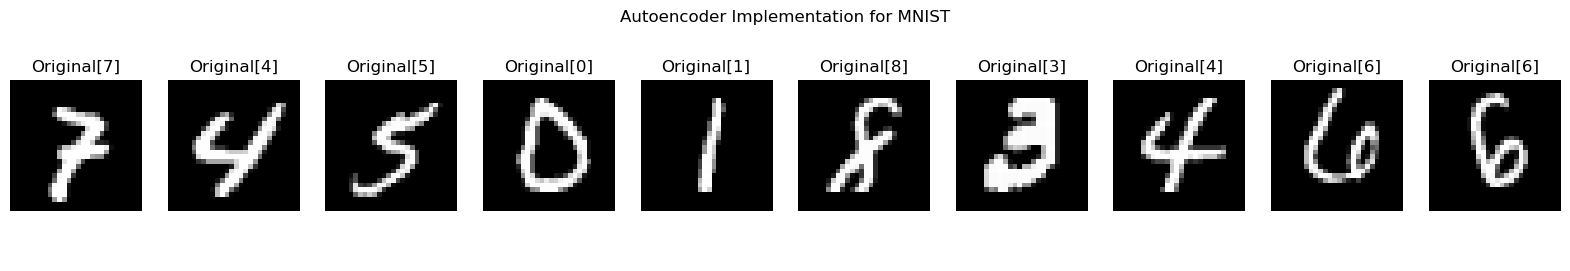

In [16]:
plot_images_single_dataset(x_train_mnist, y_train_mnist)

Plot the datasets - Fashion-MNIST

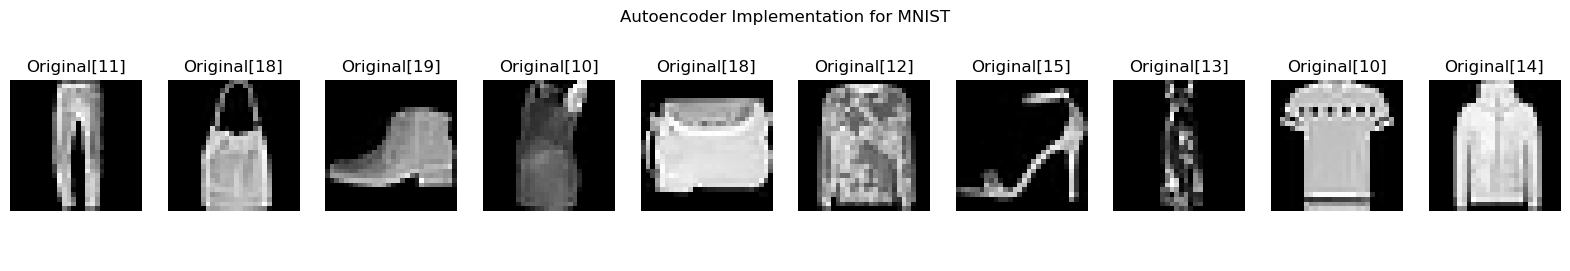

In [17]:
plot_images_single_dataset(x_train_fmnist, y_train_fmnist)

Plot the datasets - Combined (MNIST + Fashion-MNIST)

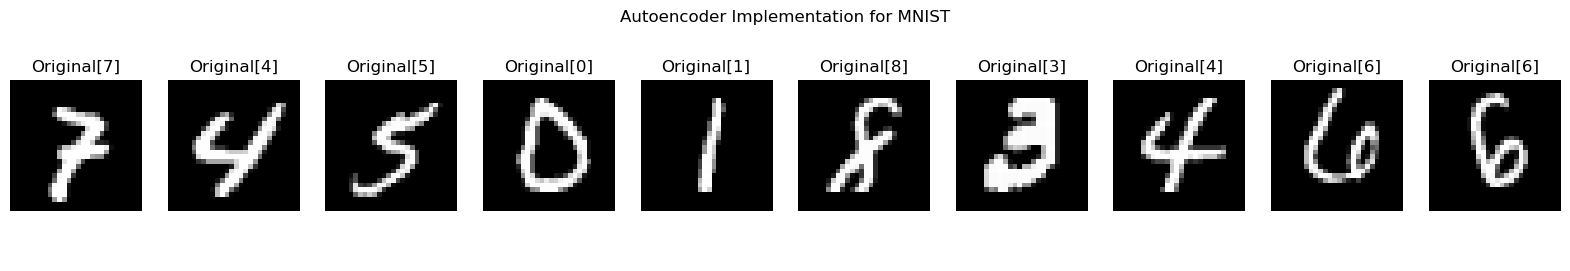

In [18]:
plot_images_single_dataset(x_train_combined, y_train_combined)

#### **Create the Dictionary Labels**

MNIST

In [19]:
uniques_mnist = np.unique(y_train_mnist)
list_lables_mnist = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
dict_labels_mnist = {i: list_lables_mnist[i] for i in range(len(list_lables_mnist))}
dict_labels_mnist

{0: '0',
 1: '1',
 2: '2',
 3: '3',
 4: '4',
 5: '5',
 6: '6',
 7: '7',
 8: '8',
 9: '9'}

Fashion MNIST

In [20]:
uniques_fminst = np.unique(y_train_fmnist)
list_lables_fminst = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
dict_labels_fminst = {i+10: list_lables_fminst[i] for i in range(len(list_lables_fminst))}
dict_labels_fminst

{0: 'T-shirt/top',
 1: 'Trouser',
 2: 'Pullover',
 3: 'Dress',
 4: 'Coat',
 5: 'Sandal',
 6: 'Shirt',
 7: 'Sneaker',
 8: 'Bag',
 9: 'Ankle boot'}

#### **Comment on differences between the datasets and potential challenges when combining them.**

---

Comment

---

## Step 2.1: Train Vanilla Autoencoder Models (Fully Connected Network Version)

#### **Vanilla Encoder (For Single Dataset Version)**

In [21]:
def create_vanilla_autoencoder(input_dim, latent_dim):
    encoder_inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(encoder_inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='relu')(x)
    encoder = Model(encoder_inputs, z, name='encoder')

    decoder_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(64, activation='relu')(decoder_inputs)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(256, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    decoder = Model(decoder_inputs, outputs, name='decoder')

    autoencoder_outputs = decoder(encoder(encoder_inputs))
    autoencoder = Model(encoder_inputs, autoencoder_outputs, name='autoencoder')

    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    
    return autoencoder, encoder, decoder

In [22]:
def plot_reconstructions_images_single_dataset(original_images, reconstructed_images, num_images=10, dataset_name='MNIST'):
    plt.figure(figsize=(20, 6))
    plt.title(f"Autoencoder Implementation for {dataset_name}")
    plt.axis('off')
    for i in range(num_images):
        ax = plt.subplot(2, num_images, i + 1)
        plt.imshow(original_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{i}]")
        plt.axis('off')
        
        ax = plt.subplot(2, num_images, i + num_images + 1)
        plt.imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Reconstructed[{i}]")
        plt.axis('off')
    plt.show()

#### **MNIST**

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1026 - val_loss: 0.0448
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0382 - val_loss: 0.0304
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0273 - val_loss: 0.0248
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0230 - val_loss: 0.0218
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0207 - val_loss: 0.0198
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0190 - val_loss: 0.0188
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0177 - val_loss: 0.0174
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0164 - val_loss: 0.0166
Epoch 9/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0154 - val_loss: 0.0158
Epoch 10/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0146 - val_loss: 0.0145
Epoch 11/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0138 - val_loss: 0.0139
Epoch 12/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

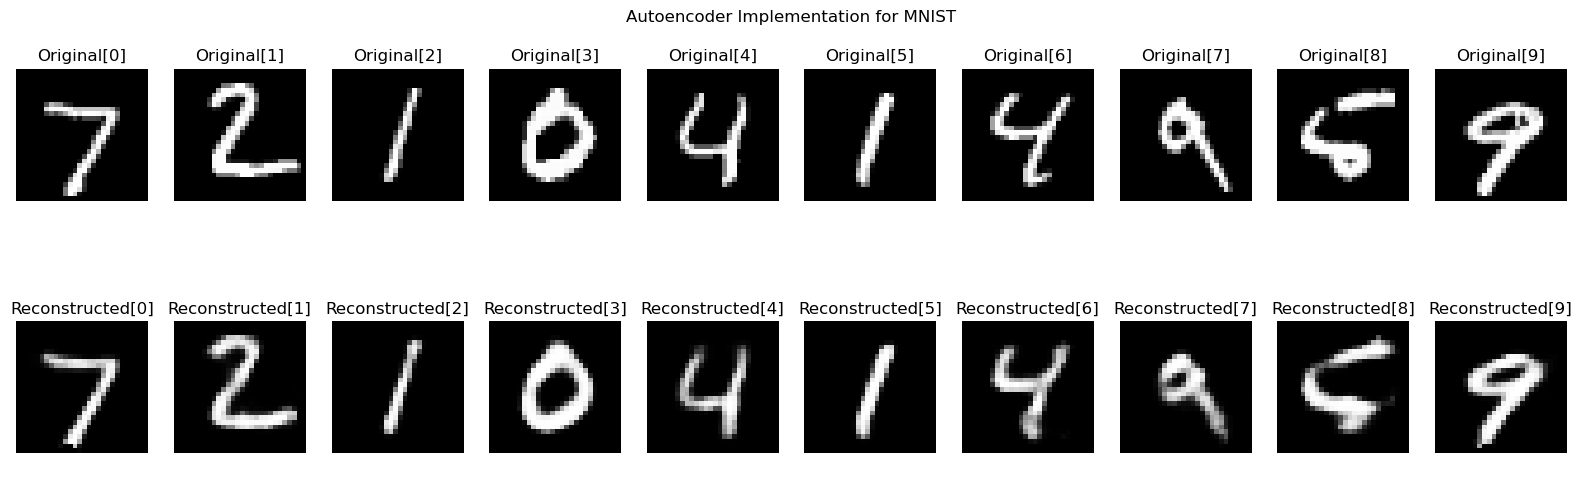

In [23]:
def autoencoder_mnist_implementation(x_train_mnist_normalized, x_val_mnist_normalized, x_test_mnist_normalized):
    input_dim = x_train_mnist_normalized.shape[1]
    latent_dim = 32

    autoencoder_mnist, encoder_mnist, decoder_mnist = create_vanilla_autoencoder(input_dim, latent_dim)

    autoencoder_mnist.fit(
        x_train_mnist_normalized,
        x_train_mnist_normalized,
        epochs=50,
        batch_size=256,
        validation_data=(x_val_mnist_normalized, x_val_mnist_normalized)
    )

    reconstructed_images = autoencoder_mnist.predict(x_test_mnist_normalized)

    mse = tf.keras.losses.MeanSquaredError()
    mse_value = mse(x_test_mnist_normalized, reconstructed_images).numpy()
    print(f"Mean Squared Error on test set: {mse_value:.6f}")

    return autoencoder_mnist, encoder_mnist, decoder_mnist, reconstructed_images

autoencoder_mnist, encoder_mnist, decoder_mnist, reconstructed_images = autoencoder_mnist_implementation(x_train_mnist_normalized, x_val_mnist_normalized, x_test_mnist_normalized)
plot_reconstructions_images_single_dataset(x_test_mnist_normalized, reconstructed_images, num_images=10, dataset_name='MNIST')

#### **Fashion-MNIST**

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0861 - val_loss: 0.0321
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0270 - val_loss: 0.0229
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0219 - val_loss: 0.0205
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0197 - val_loss: 0.0192
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0187 - val_loss: 0.0181
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0177 - val_loss: 0.0177
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0171 - val_loss: 0.0172
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0164 - val_loss: 0.0163
Epoch 9/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0159 - val_loss: 0.0161
Epoch 10/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 0.0157 - val_loss: 0.0152
Epoch 11/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0150 - val_loss: 0.0152
Epoch 12/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 

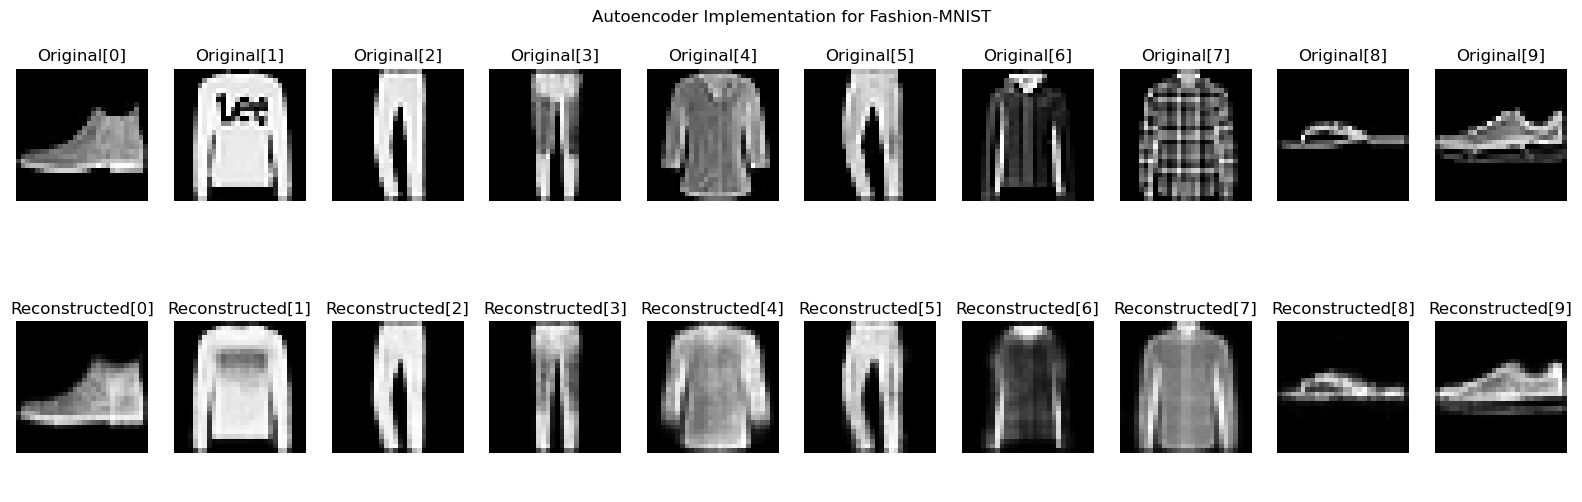

In [24]:
def autoencoder_mnist_fashion_implementation(x_train_fmnist_fashsion_normalized, x_val_fmnist_fashsion_normalized, x_test_fmnist_fashsion_normalized):
    input_dim = x_train_fmnist_fashsion_normalized.shape[1]
    latent_dim = 32

    autoencoder_mnist_fashion, encoder_mnist_fashion, decoder_mnist_fashion = create_vanilla_autoencoder(input_dim, latent_dim)

    autoencoder_mnist_fashion.fit(
        x_train_fmnist_fashsion_normalized,
        x_train_fmnist_fashsion_normalized,
        epochs=50,
        batch_size=256,
        validation_data=(x_val_fmnist_fashsion_normalized, x_val_fmnist_fashsion_normalized)
    )

    reconstructed_images_fashion = autoencoder_mnist_fashion.predict(x_test_fmnist_fashsion_normalized)

    mse = tf.keras.losses.MeanSquaredError()
    mse_value = mse(x_test_fmnist_fashsion_normalized, reconstructed_images_fashion).numpy()
    print(f"Mean Squared Error on test set: {mse_value:.6f}")

    return autoencoder_mnist_fashion, encoder_mnist_fashion, decoder_mnist_fashion, reconstructed_images_fashion

autoencoder_mnist_fashion, encoder_mnist_fashion, decoder_mnist_fashion, reconstructed_images_fashion = autoencoder_mnist_fashion_implementation(x_train_fmnist_normalized, x_val_fmnist_normalized, x_test_fmnist_normalized)
plot_reconstructions_images_single_dataset(x_test_fmnist_normalized, reconstructed_images_fashion, num_images=10, dataset_name='Fashion-MNIST')

#### **Vanilla Encoder (For Combined Dataset Version)**

#### Combined Data

In [25]:
def create_vanilla_autoencoder_combined_version(input_dim, latent_dim):
    encoder_inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(512, activation='relu')(encoder_inputs)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    z = layers.Dense(latent_dim, activation='relu')(x)
    encoder = Model(encoder_inputs, z, name='encoder')

    decoder_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(128, activation='relu')(decoder_inputs)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(512, activation='relu')(x)
    outputs = layers.Dense(input_dim, activation='sigmoid')(x)
    decoder = Model(decoder_inputs, outputs, name='decoder')

    autoencoder_outputs = decoder(encoder(encoder_inputs))
    autoencoder = Model(encoder_inputs, autoencoder_outputs, name='autoencoder')

    autoencoder.compile(optimizer='adam', loss='mean_squared_error')
    
    return autoencoder, encoder, decoder

In [26]:
def plot_reconstructions_images_combined_dataset(original_images, reconstructed_images, num_images=10, dataset_name='MNIST'):
    plt.figure(figsize=(20, 10))
    plt.title(f"Autoencoder Implementation for {dataset_name}")
    plt.axis('off')
    for i in range(num_images):
        ax = plt.subplot(4, num_images, i + 1)
        plt.imshow(original_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{i}]")
        plt.axis('off')
        
        ax = plt.subplot(4, num_images, i + num_images + 1)
        plt.imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
        plt.title(f"Reconstructed[{i}]")
        plt.axis('off')

    for i in range(num_images):
        ax = plt.subplot(4, num_images, i + num_images * 2 + 1)
        plt.imshow(original_images[-i].reshape(28, 28), cmap='gray')
        plt.title(f"Original[{i}]")
        plt.axis('off')
        
        ax = plt.subplot(4, num_images, i + num_images * 3 + 1)
        plt.imshow(reconstructed_images[-i].reshape(28, 28), cmap='gray')
        plt.title(f"Reconstructed[{i}]")
        plt.axis('off')

    plt.show()

Epoch 1/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.0760 - val_loss: 0.0284
Epoch 2/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0257 - val_loss: 0.0210
Epoch 3/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0199 - val_loss: 0.0181
Epoch 4/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0173 - val_loss: 0.0162
Epoch 5/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0155 - val_loss: 0.0154
Epoch 6/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0143 - val_loss: 0.0145
Epoch 7/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0135 - val_loss: 0.0136
Epoch 8/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0128 - val_loss: 0.0129
Epoch 9/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0122 - val_loss: 0.0124
Epoch 10/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0118 - val_loss: 0.0122
Epoch 11/50
329/329 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 0.0113 - val_loss: 0.0116
Epoch 12/50
329/329 ━━━━━━━━━━━━━━━━━━━━

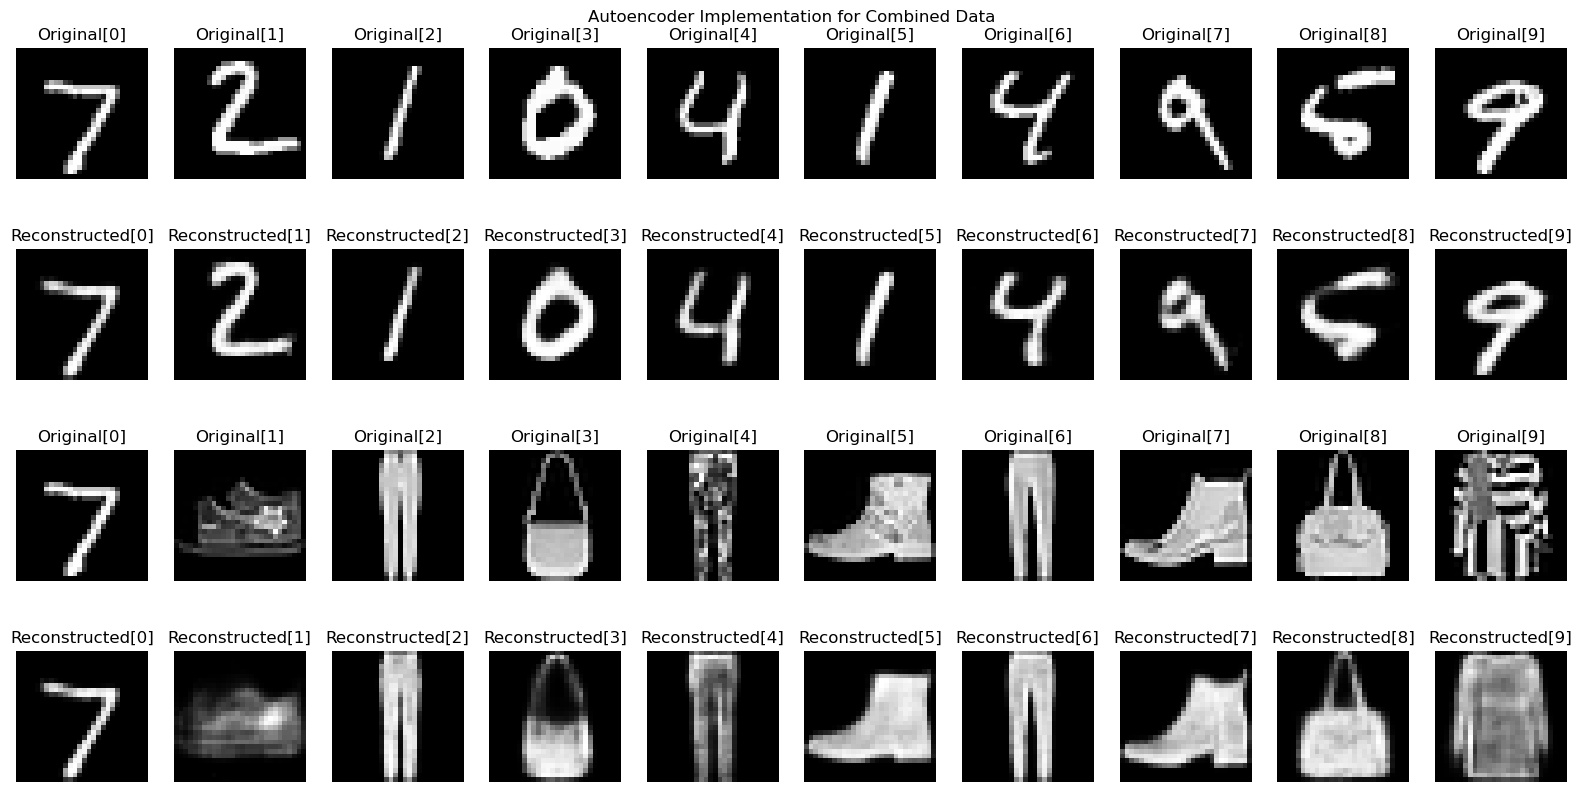

In [27]:
def autoencoder_mnist_combined_implementation(x_train_combined_normalized, x_val_combined_normalized, x_test_combined_normalized):
    input_dim = x_train_combined_normalized.shape[1]
    latent_dim = 32

    autoencoder_mnist_combined, encoder_mnist_combined, decoder_mnist_combined = create_vanilla_autoencoder_combined_version(input_dim, latent_dim)

    autoencoder_mnist_combined.fit(
        x_train_combined_normalized,
        x_train_combined_normalized,
        epochs=50,
        batch_size=256,
        validation_data=(x_val_combined_normalized, x_val_combined_normalized)
    )

    reconstructed_images_combined = autoencoder_mnist_combined.predict(x_test_combined_normalized)

    mse = tf.keras.losses.MeanSquaredError()
    mse_value = mse(x_test_combined_normalized, reconstructed_images_combined).numpy()
    print(f"Mean Squared Error on test set: {mse_value:.6f}")

    return autoencoder_mnist_combined, encoder_mnist_combined, decoder_mnist_combined, reconstructed_images_combined

autoencoder_mnist_combined, encoder_mnist_combined, decoder_mnist_combined, reconstructed_images_combined = autoencoder_mnist_combined_implementation(x_train_combined_normalized, x_val_combined_normalized, x_test_combined_normalized)
plot_reconstructions_images_combined_dataset(x_test_combined_normalized, reconstructed_images_combined, num_images=10, dataset_name='Combined Data')

## Step 2.2: Train CNN Vanilla Autoencoder Models

#### **Vanilla Encoder (For Single Dataset Version)**

In [48]:
def create_cnn_vanilla_autoencoder():
    encoder_inputs = layers.Input(shape=(28, 28, 1))
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoder_inputs)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)
    encoder = Model(encoder_inputs, encoded, name='encoder')

    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(16, (3, 3), activation='relu')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    decoder = Model(encoded, decoded, name='decoder')

    autoencoder_outputs = decoder(encoder(encoder_inputs))
    autoencoder = Model(encoder_inputs, autoencoder_outputs, name='autoencoder')
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    
    return autoencoder, encoder, decoder

In [49]:
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()

(x_train_fmnist, y_train_fmnist), (x_test_fmnist, y_test_fmnist) = tf.keras.datasets.fashion_mnist.load_data()

In [50]:
print(np.unique(y_train_fmnist))
y_train_fmnist = np.array(y_train_fmnist)
y_train_fmnist += 10
print(np.unique(y_train_fmnist))

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]


In [51]:
print(np.unique(y_test_fmnist))
y_test_fmnist = np.array(y_test_fmnist)
y_test_fmnist += 10
print(np.unique(y_test_fmnist))

[0 1 2 3 4 5 6 7 8 9]
[10 11 12 13 14 15 16 17 18 19]


In [52]:
x_train_mnist_normalized = x_train_mnist / 255.0
x_test_mnist_normalized = x_test_mnist / 255.0

x_train_fmnist_normalized = x_train_fmnist / 255.0
x_test_fmnist_normalized = x_test_fmnist / 255.0

In [53]:
x_train_combined = np.concatenate([x_train_mnist_normalized, x_train_fmnist_normalized], axis=0)
y_train_combined = np.concatenate([y_train_mnist, y_train_fmnist], axis=0)

x_test_combined = np.concatenate([x_test_mnist_normalized, x_test_fmnist_normalized], axis=0)
y_test_combined = np.concatenate([y_test_mnist, y_test_fmnist], axis=0)

In [54]:
uniques_mnist = np.unique(y_train_mnist)
list_lables_mnist = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]
dict_labels_mnist = {i: list_lables_mnist[i] for i in range(len(list_lables_mnist))}
dict_labels_mnist

{0: '0',
 1: '1',
 2: '2',
 3: '3',
 4: '4',
 5: '5',
 6: '6',
 7: '7',
 8: '8',
 9: '9'}

In [55]:
uniques_fminst = np.unique(y_train_fmnist)
list_lables_fminst = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
dict_labels_fminst = {i+10: list_lables_fminst[i] for i in range(len(list_lables_fminst))}
dict_labels_fminst

{10: 'T-shirt/top',
 11: 'Trouser',
 12: 'Pullover',
 13: 'Dress',
 14: 'Coat',
 15: 'Sandal',
 16: 'Shirt',
 17: 'Sneaker',
 18: 'Bag',
 19: 'Ankle boot'}

In [56]:
x_train_mnist, x_val_mnist, y_train_mnist, y_val_mnist = train_test_split(
    x_train_mnist_normalized, y_train_mnist, test_size=0.3, random_state=42
)

x_train_fmnist, x_val_fmnist, y_train_fmnist, y_val_fmnist = train_test_split(
    x_train_fmnist_normalized, y_train_fmnist, test_size=0.3, random_state=42
)

x_train_combined, x_val_combined, y_train_combined, y_val_combined = train_test_split(
    x_train_combined, y_train_combined, test_size=0.3, random_state=42
)

In [57]:
x_train_mnist_processed = np.expand_dims(x_train_mnist, -1)
x_train_fmnist_processed = np.expand_dims(x_train_fmnist, -1)
x_train_combined_processed = np.expand_dims(x_train_combined, -1)

x_val_mnist_processed = np.expand_dims(x_val_mnist, -1)
x_val_fmnist_processed = np.expand_dims(x_val_fmnist, -1)
x_val_combined_processed = np.expand_dims(x_val_combined, -1)

x_test_mnist_processed = np.expand_dims(x_test_mnist, -1)
x_test_fmnist_processed = np.expand_dims(x_test_fmnist, -1)
x_test_combined_processed = np.expand_dims(x_test_combined, -1)

#### MNIST Dataset

Epoch 1/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.4478 - val_loss: 0.1917
Epoch 2/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1800 - val_loss: 0.1597
Epoch 3/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.1554 - val_loss: 0.1453
Epoch 4/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.1415 - val_loss: 0.1342
Epoch 5/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.1319 - val_loss: 0.1281
Epoch 6/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1258 - val_loss: 0.1227
Epoch 7/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1219 - val_loss: 0.1202
Epoch 8/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1193 - val_loss: 0.1178
Epoch 9/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1172 - val_loss: 0.1159
Epoch 10/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1153 - val_loss: 0.1153
Epoch 11/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.1143 - val_loss: 0.1135
Epoch 12/50
165/165 ━━━━━━━━━━━━━━━━━━━━ 

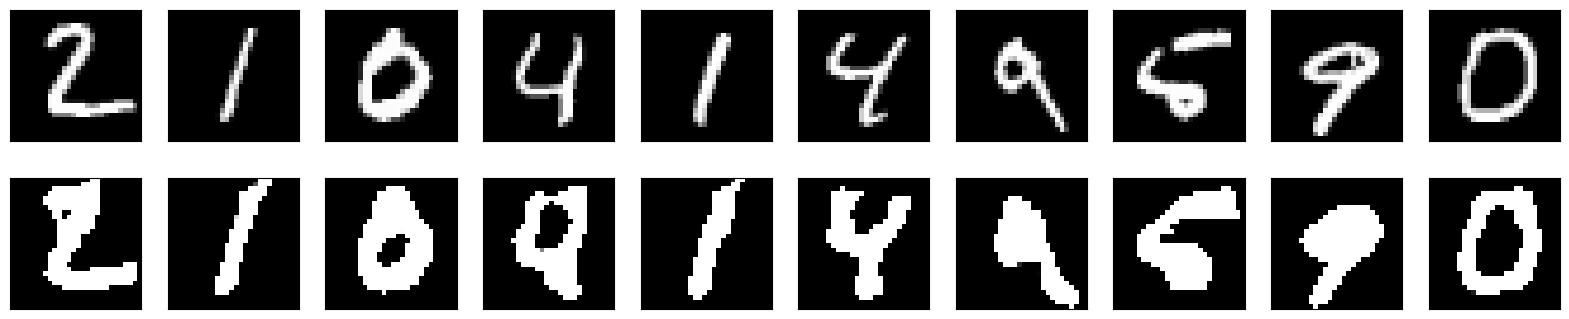

In [ ]:
autoencoder_mnist_cnn, encoder_mnist_cnn, decoder_mnist_cnn = create_cnn_vanilla_autoencoder()

autoencoder_mnist_cnn.fit(x_train_mnist_processed, x_train_mnist_processed,
                epochs=50,
                batch_size=256,
                shuffle=True,
                validation_data=(x_val_mnist_processed, x_val_mnist_processed))

decoded_imgs_mnist = autoencoder_mnist_cnn.predict(x_test_mnist_processed)

n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test_mnist_processed[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs_mnist[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

x_test_encoded_mnist_cnn = encoder_mnist_cnn.predict(x_test_mnist_processed)
plt.figure(figsize=(12, 10))
plt.scatter(x_test_encoded_mnist_cnn[:,0,0,0], x_test_encoded_mnist_cnn[:,1,1,1], c=y_test_mnist)
plt.colorbar()
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.show()

#### Fashion MNIST Dataset

Epoch 1/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 0.3767 - val_loss: 0.2997
Epoch 2/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 0.2979 - val_loss: 0.2934
Epoch 3/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 0.2914 - val_loss: 0.2896
Epoch 4/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2891 - val_loss: 0.2876
Epoch 5/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2868 - val_loss: 0.2857
Epoch 6/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2844 - val_loss: 0.2845
Epoch 7/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2841 - val_loss: 0.2837
Epoch 8/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2827 - val_loss: 0.2828
Epoch 9/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.2824 - val_loss: 0.2820
Epoch 10/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.2817 - val_loss: 0.2814
Epoch 11/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.2811 - val_loss: 0.2808
Epoch 12/50
1313/1313

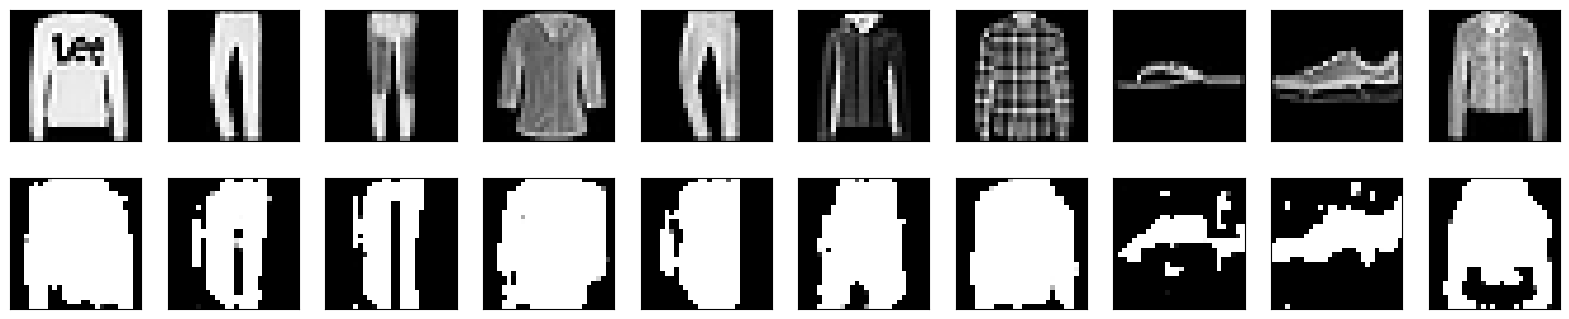

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


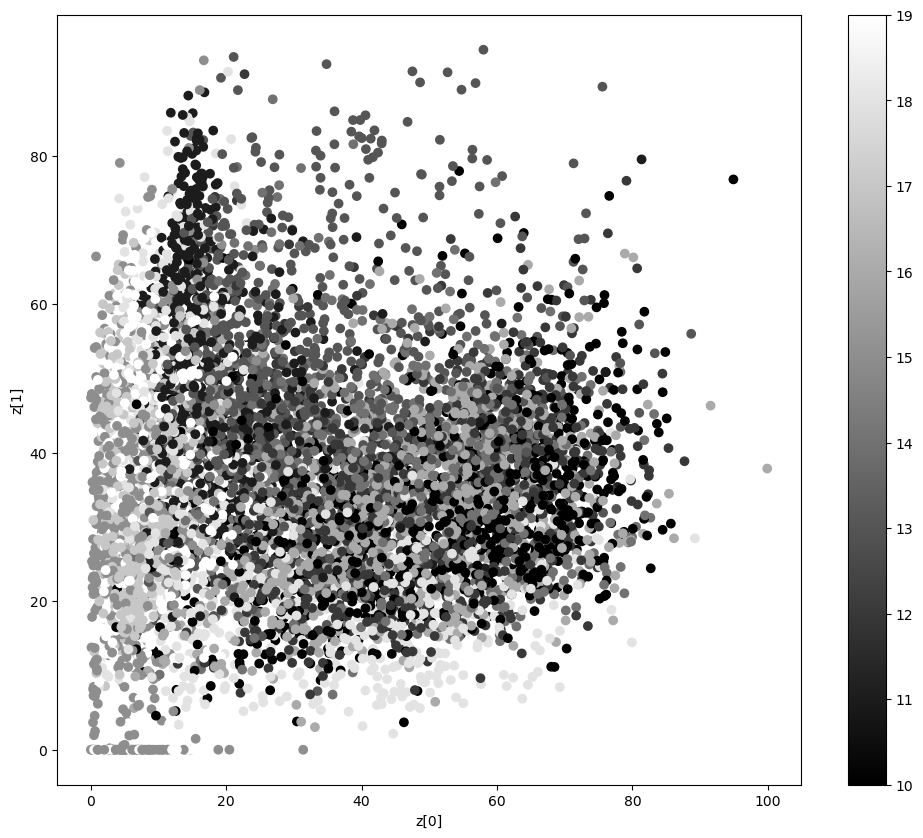

In [108]:
autoencoder_fmnist_cnn, encoder_fmnist_cnn, decoder_fmnist_cnn = create_cnn_vanilla_autoencoder()

autoencoder_fmnist_cnn.fit(x_train_fmnist_processed, x_train_fmnist_processed,
                epochs=50,
                batch_size=32,
                shuffle=True,
                validation_data=(x_val_fmnist_processed, x_val_fmnist_processed))

decoded_imgs_fmnist = autoencoder_fmnist_cnn.predict(x_test_fmnist_processed)

n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test_fmnist_processed[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs_fmnist[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

x_test_encoded_fmnist_cnn = encoder_fmnist_cnn.predict(x_test_fmnist_processed)
plt.figure(figsize=(12, 10))
plt.scatter(x_test_encoded_fmnist_cnn[:,0,0,0], x_test_encoded_fmnist_cnn[:,1,1,1], c=y_test_fmnist)
plt.colorbar()
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.show()

#### Combined Dataset

Epoch 1/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 23s 8ms/step - loss: 0.2866 - val_loss: 0.2111
Epoch 2/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.2096 - val_loss: 0.2021
Epoch 3/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.2020 - val_loss: 0.1975
Epoch 4/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.1987 - val_loss: 0.1948
Epoch 5/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.1964 - val_loss: 0.1937
Epoch 6/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.1946 - val_loss: 0.1922
Epoch 7/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.1938 - val_loss: 0.1915
Epoch 8/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 0.1929 - val_loss: 0.1904
Epoch 9/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.1918 - val_loss: 0.1907
Epoch 10/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.1916 - val_loss: 0.1896
Epoch 11/50
2625/2625 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.1909 - val_loss: 0.1893
Epoch 12/50
2625/26

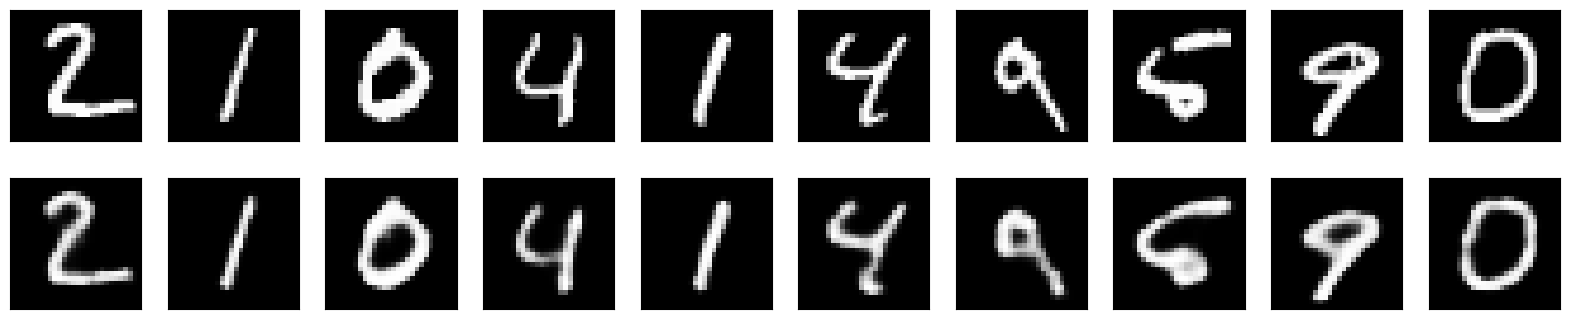

625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


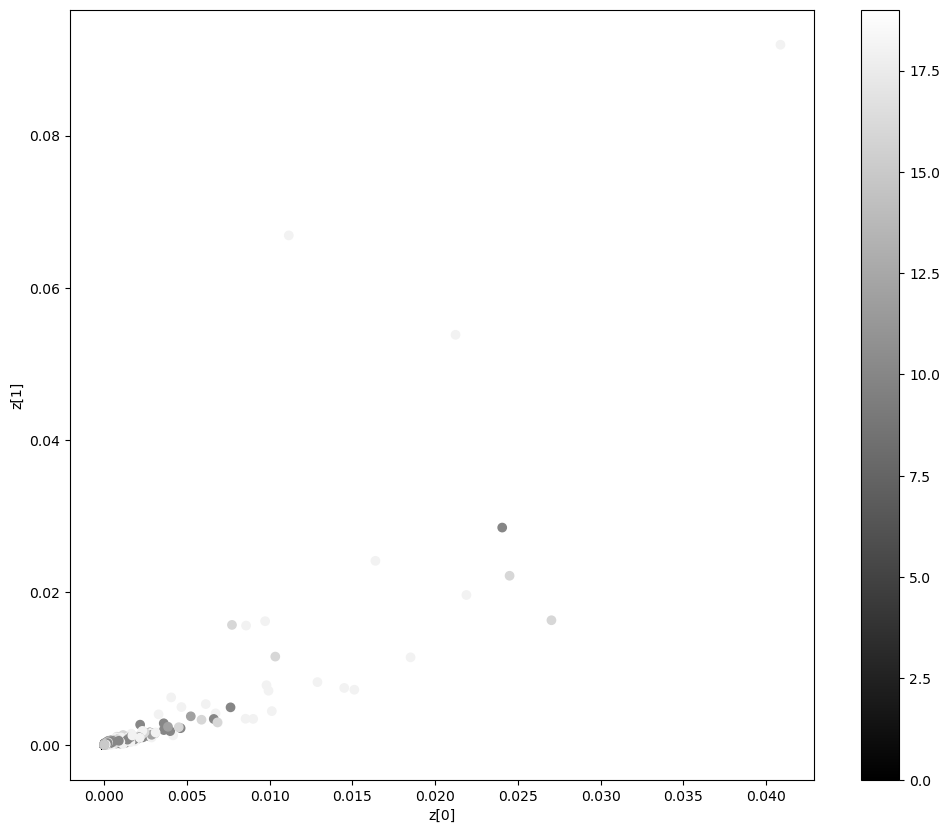

In [117]:
autoencoder_combined_cnn, encoder_combined_cnn, decoder_combined_cnn = create_cnn_vanilla_autoencoder()

autoencoder_combined_cnn.fit(x_train_combined_processed, x_train_combined_processed,
                epochs=50,
                batch_size=32,
                shuffle=True,
                validation_data=(x_val_combined_processed, x_val_combined_processed))

decoded_imgs_combined = autoencoder_combined_cnn.predict(x_test_combined_processed)

n = 10
plt.figure(figsize=(20, 4))
for i in range(1, n + 1):
    ax = plt.subplot(2, n, i)
    plt.imshow(x_test_combined_processed[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs_combined[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

x_test_encoded_combined_cnn = autoencoder_combined_cnn.predict(x_test_combined_processed)
plt.figure(figsize=(12, 10))
plt.scatter(x_test_encoded_combined_cnn[:,0,0], x_test_encoded_combined_cnn[:,1,1], c=y_test_combined)
plt.colorbar()
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.show()